In [53]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
%matplotlib inline

In [54]:
df = pd.read_csv('..\\data\\IndianFlightdata - Sheet1.csv')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [56]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [57]:
df['day_of_week'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

df['Date'] = df['Date_of_Journey'].str.split('/').str[0].astype(int)
df['Month'] = df['Date_of_Journey'].str.split('/').str[1].astype(int)
df['year'] = df['Date_of_Journey'].str.split('/').str[2].astype(int)


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
 11  day_of_week      10683 non-null  int32
 12  is_weekend       10683 non-null  int64
 13  Date             10683 non-null  int64
 14  Month            10683 non-null  int64
 15  year             10683 non-null  int64
dtypes: int32(1), int64(5), str(10)
memory usage: 1.3 MB


In [59]:
df.drop('Date_of_Journey',axis=1,inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Source           10683 non-null  str  
 2   Destination      10683 non-null  str  
 3   Route            10682 non-null  str  
 4   Dep_Time         10683 non-null  str  
 5   Arrival_Time     10683 non-null  str  
 6   Duration         10683 non-null  str  
 7   Total_Stops      10682 non-null  str  
 8   Additional_Info  10683 non-null  str  
 9   Price            10683 non-null  int64
 10  day_of_week      10683 non-null  int32
 11  is_weekend       10683 non-null  int64
 12  Date             10683 non-null  int64
 13  Month            10683 non-null  int64
 14  year             10683 non-null  int64
dtypes: int32(1), int64(5), str(9)
memory usage: 1.2 MB


In [60]:
df['Arrival_Time']= df['Arrival_Time'].apply( lambda x:x.split(' ')[0])
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,day_of_week,is_weekend,Date,Month,year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,6,1,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,2,0,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,1,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,6,1,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,4,0,1,3,2019


In [61]:
df['Arrival_hour']= df['Arrival_Time'].str.split(':').str[0].astype(int)
df['Arrival_Minute']= df['Arrival_Time'].str.split(':').str[1].astype(int)
df['Dep_hour']= df['Dep_Time'].str.split(':').str[0].astype(int)
df['Dep_Minute']= df['Dep_Time'].str.split(':').str[1].astype(int)
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,day_of_week,is_weekend,Date,Month,year,Arrival_hour,Arrival_Minute,Dep_hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,6,1,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,2,0,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,1,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,6,1,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,4,0,1,3,2019,21,35,16,50


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Source           10683 non-null  str  
 2   Destination      10683 non-null  str  
 3   Route            10682 non-null  str  
 4   Dep_Time         10683 non-null  str  
 5   Arrival_Time     10683 non-null  str  
 6   Duration         10683 non-null  str  
 7   Total_Stops      10682 non-null  str  
 8   Additional_Info  10683 non-null  str  
 9   Price            10683 non-null  int64
 10  day_of_week      10683 non-null  int32
 11  is_weekend       10683 non-null  int64
 12  Date             10683 non-null  int64
 13  Month            10683 non-null  int64
 14  year             10683 non-null  int64
 15  Arrival_hour     10683 non-null  int64
 16  Arrival_Minute   10683 non-null  int64
 17  Dep_hour         10683 non-null  int64
 18  Dep_Minute       

In [63]:
df.drop ('Arrival_Time',axis=1, inplace=True)
df.drop ('Dep_Time',axis=1, inplace=True)


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Source           10683 non-null  str  
 2   Destination      10683 non-null  str  
 3   Route            10682 non-null  str  
 4   Duration         10683 non-null  str  
 5   Total_Stops      10682 non-null  str  
 6   Additional_Info  10683 non-null  str  
 7   Price            10683 non-null  int64
 8   day_of_week      10683 non-null  int32
 9   is_weekend       10683 non-null  int64
 10  Date             10683 non-null  int64
 11  Month            10683 non-null  int64
 12  year             10683 non-null  int64
 13  Arrival_hour     10683 non-null  int64
 14  Arrival_Minute   10683 non-null  int64
 15  Dep_hour         10683 non-null  int64
 16  Dep_Minute       10683 non-null  int64
dtypes: int32(1), int64(9), str(7)
memory usage: 1.3 MB


In [65]:
df['Total_Stops'].unique()

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']
Length: 6, dtype: str

In [66]:
df[df['Total_Stops'].isnull()]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,day_of_week,is_weekend,Date,Month,year,Arrival_hour,Arrival_Minute,Dep_hour,Dep_Minute
9039,Air India,Delhi,Cochin,NaN,23h 40m,NaN,No info,7480,0,0,6,5,2019,9,25,9,45


In [67]:
df['Total_Stops'].mode()

0    1 stop
Name: Total_Stops, dtype: str

In [68]:
df['Total_Stops'].unique()

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']
Length: 6, dtype: str

In [69]:
df['Total_Stops'].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
10678    False
10679    False
10680    False
10681    False
10682    False
Name: Total_Stops, Length: 10683, dtype: bool

In [70]:
df['Total_Stops']=df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,np.nan:1})

In [71]:
df[df['Total_Stops'].isnull()]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,day_of_week,is_weekend,Date,Month,year,Arrival_hour,Arrival_Minute,Dep_hour,Dep_Minute


In [72]:
df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,day_of_week,is_weekend,Date,Month,year,Arrival_hour,Arrival_Minute,Dep_hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897,6,1,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,2,0,1,5,2019,13,15,5,50


In [73]:
df.drop('Route',axis=1,inplace=True)
df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,day_of_week,is_weekend,Date,Month,year,Arrival_hour,Arrival_Minute,Dep_hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897,6,1,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662,2,0,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882,6,1,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218,6,1,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302,4,0,1,3,2019,21,35,16,50


In [74]:
df['Duration'].str.split(' ').str[0].str.split('h').str[0]

0         2
1         7
2        19
3         5
4         4
         ..
10678     2
10679     2
10680     3
10681     2
10682     8
Name: Duration, Length: 10683, dtype: object

In [75]:
df['Airline'].unique

<bound method Series.unique of 0             IndiGo
1          Air India
2        Jet Airways
3             IndiGo
4             IndiGo
            ...     
10678       Air Asia
10679      Air India
10680    Jet Airways
10681        Vistara
10682      Air India
Name: Airline, Length: 10683, dtype: str>

In [76]:
df['Source'].unique

<bound method Series.unique of 0        Banglore
1         Kolkata
2           Delhi
3         Kolkata
4        Banglore
           ...   
10678     Kolkata
10679     Kolkata
10680    Banglore
10681    Banglore
10682       Delhi
Name: Source, Length: 10683, dtype: str>

In [77]:
df["Additional_Info"].unique

<bound method Series.unique of 0        No info
1        No info
2        No info
3        No info
4        No info
          ...   
10678    No info
10679    No info
10680    No info
10681    No info
10682    No info
Name: Additional_Info, Length: 10683, dtype: str>

In [78]:
from sklearn.preprocessing import OneHotEncoder
encoder= OneHotEncoder()
encoder.fit_transform(df[['Airline','Source','Destination']]).toarray()

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(10683, 23))

In [79]:
pd.DataFrame(encoder.fit_transform(df[['Airline','Source','Destination']]).toarray(),columns=encoder.get_feature_names_out())

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10680,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


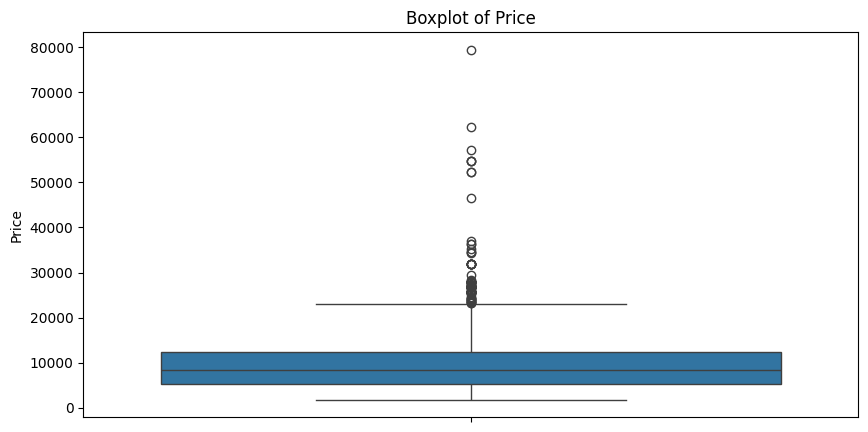

In [80]:
#IQR
plt.figure(figsize=(10,5))
sns.boxplot(df['Price'])
plt.title('Boxplot of Price')
plt.show()

In [81]:
Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [82]:
df=df[(df['Price']>=lower_bound) & (df['Price']<=upper_bound)]
print(f"upper_bound: {upper_bound}")
print(f"shape of data after removing outliers: {df.shape[0]}")

upper_bound: 23017.0
shape of data after removing outliers: 10589


In [83]:
#Numerical features
def convert_duration(x):
    if 'h' in x and 'm' in x:
        hours = int(x.split('h')[0])
        minutes = int(x.split('h')[1].split('m')[0])
        return hours * 60 + minutes
    elif 'h' in x:
        hours = int(x.split('h')[0])
        return hours * 60
    elif 'm' in x:
        minutes = int(x.split('m')[0])
        return minutes
    else:
        return 0

df['Duration_minutes'] = df['Duration'].apply(convert_duration)

df.drop(['Duration', 'Additional_Info'], axis=1, inplace=True)
df.head()

,Airline,Source,Destination,Total_Stops,Price,day_of_week,is_weekend,Date,Month,year,Arrival_hour,Arrival_Minute,Dep_hour,Dep_Minute,Duration_minutes
0,IndiGo,Banglore,New Delhi,0,3897,6,1,24,3,2019,1,10,22,20,170
1,Air India,Kolkata,Banglore,2,7662,2,0,1,5,2019,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,2,13882,6,1,9,6,2019,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,1,6218,6,1,12,5,2019,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,1,13302,4,0,1,3,2019,21,35,16,50,285


In [84]:
#Encoding categorical features
encoded_df = pd.DataFrame(encoder.fit_transform(df[['Airline','Source','Destination']]).toarray(), columns=encoder.get_feature_names_out())
df = df.reset_index(drop=True)
df=pd.concat([df, encoded_df], axis=1)
df.drop(['Airline','Source','Destination'], axis=1, inplace=True)
df.head()

,Total_Stops,Price,day_of_week,is_weekend,Date,Month,year,Arrival_hour,Arrival_Minute,Dep_hour,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,6,1,24,3,2019,1,10,22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,7662,2,0,1,5,2019,13,15,5,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,13882,6,1,9,6,2019,4,25,9,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,6218,6,1,12,5,2019,23,30,18,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,13302,4,0,1,3,2019,21,35,16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [85]:
#save data to csv file
import os
output_dir = '..\\data\\data_for_assignment'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [86]:
output_path = os.path.join(output_dir, 'cleaned_flight_data.csv')
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to: {output_path}")

Cleaned data saved to: ..\data\data_for_assignment\cleaned_flight_data.csv
